Imamo tri tabele s podatki:
1) *flights* - Vsebuje informacije o vsakem letu (končni status, številka leta, letališče prihoda, čas leta, predvideni in dejanski čas vzleta in pristanka, letalska družba, letalo...)
2) *airports* - Vsebuje informacije o letališčih prihoda (koda IATA, ime, mesto, država, časovni pas, regija)
3) *aircrafts* - Vsebuje podatke o uporabljenem letalu (njihovo ime, domet, število potnikov)

In [2]:
import pandas as pd
from cas import Cas, into_minutes
flights = pd.read_csv("podatki/flights.csv", index_col="flightId")
airports = pd.read_csv("podatki/arrivalAirport.csv", index_col='fs')
aircrafts = pd.read_csv('podatki/equipment.csv', index_col='id')


Uporabljam tortni grafikon za prikaz razmerja med pravočasnimi odhodi, zamudami in odpovedmi letov:

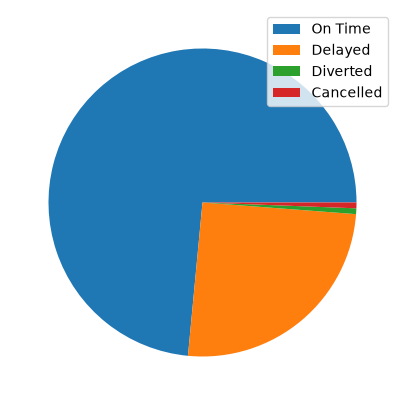

In [3]:
ax = flights["finalStatus"].value_counts().plot.pie(
    labels=None,
    figsize=(5, 5)
)
ax.legend(flights["finalStatus"].value_counts().index)

Graf povprečne zamude za vsako letalsko družbo:

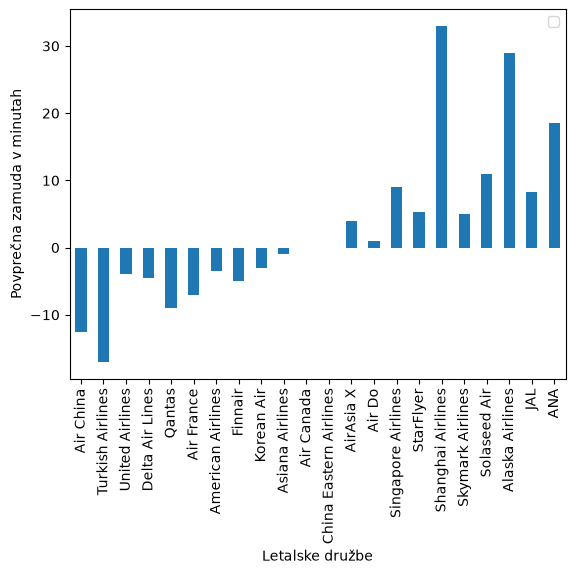

In [5]:
def odstevanje(cas1, cas2):
    if cas1 > cas2:
        return into_minutes(cas1 - cas2)
    return -into_minutes(cas2 - cas1)

carrier_delays = flights[flights.finalStatus != 'Cancelled']
carrier_delays = carrier_delays[['depTimeActual', 'depTimeScheduled', 'carrier']]
carrier_delays['depTimeActual'] = carrier_delays['depTimeActual'].apply(Cas)
carrier_delays['depTimeScheduled'] = carrier_delays['depTimeScheduled'].apply(Cas)
carrier_delays['delay'] = carrier_delays.apply(
    lambda red: odstevanje(red["depTimeActual"], red["depTimeScheduled"]),
    axis=1
)
c1 = carrier_delays.groupby("carrier")["delay"].sum().rename('c1').sort_values()
c2 = carrier_delays.groupby("carrier")["delay"].count().rename('c2').sort_values()

merged = pd.merge(c1, c2, left_on='carrier', right_on='carrier')
merged['average_delay'] = merged['c1'] / merged['c2']
ax = merged[['average_delay']].plot.bar()
ax.set_xlabel('Letalske družbe')
ax.set_ylabel('Povprečna zamuda v minutah')
ax.legend('')


Zamude letov niso odvisne od predvidenega časa odhoda:

[]

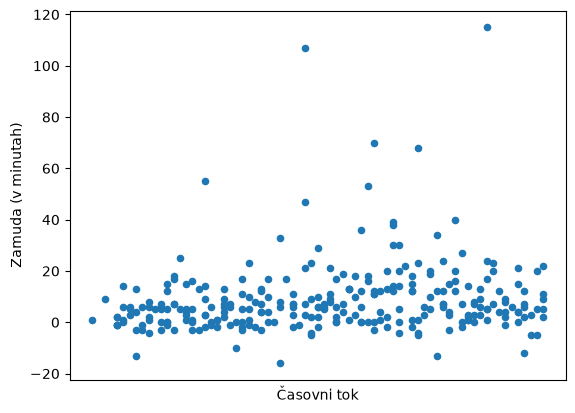

In [ ]:
carrier_delays = carrier_delays[['depTimeScheduled','delay']]
carrier_delays['depTimeScheduled'] = carrier_delays['depTimeScheduled'].apply(into_minutes)
ax = carrier_delays.plot.scatter(x="depTimeScheduled", y="delay")
ax.set_ylabel('Zamuda (v minutah)')
ax.set_xlabel('Časovni tok')
ax.set_xticks([])
#carrier_delay


V katera mesta se najpogosteje leti? Modra barva označuje število potnikov v to mesto, rdeča pa število letov. Največje število letov ne pomeni največjega števila potnikov.

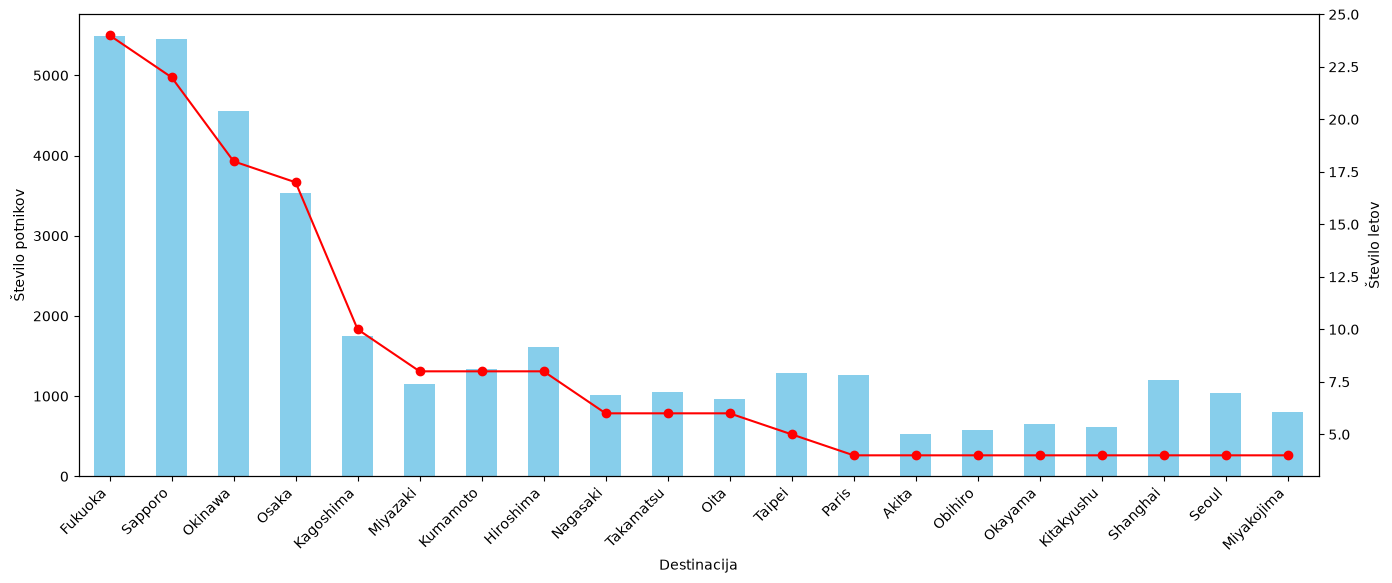

In [ ]:
m = pd.merge(flights, airports, left_on='arrivalAirportFS', right_on='fs')
merged = pd.merge(m, aircrafts, left_on='equipment', right_on='id')
t1 = (
    merged.groupby('city')['pax']
    .count()
    .rename('stevilo_letov')
    .sort_values(ascending=False))
t2 = (
    merged.groupby('city')['pax']
    .sum()
    .rename('stevilo_potnikov')
    .sort_values(ascending=False))
top_destinacije = pd.merge(t1, t2, left_on='city', right_on='city').head(20)

ax = top_destinacije["stevilo_potnikov"].plot.bar(figsize=(16, 6), color="skyblue")
top_destinacije["stevilo_letov"].plot(ax=ax, secondary_y=True, color="red", marker="o")
ax.set_xlabel('Destinacija')
ax.set_ylabel("Število potnikov")
ax.right_ax.set_ylabel("Število letov")
_ = ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")

V katere države zunaj Japonske se najpogosteje leti? V tem primeru je število letov sorazmerno s številom.

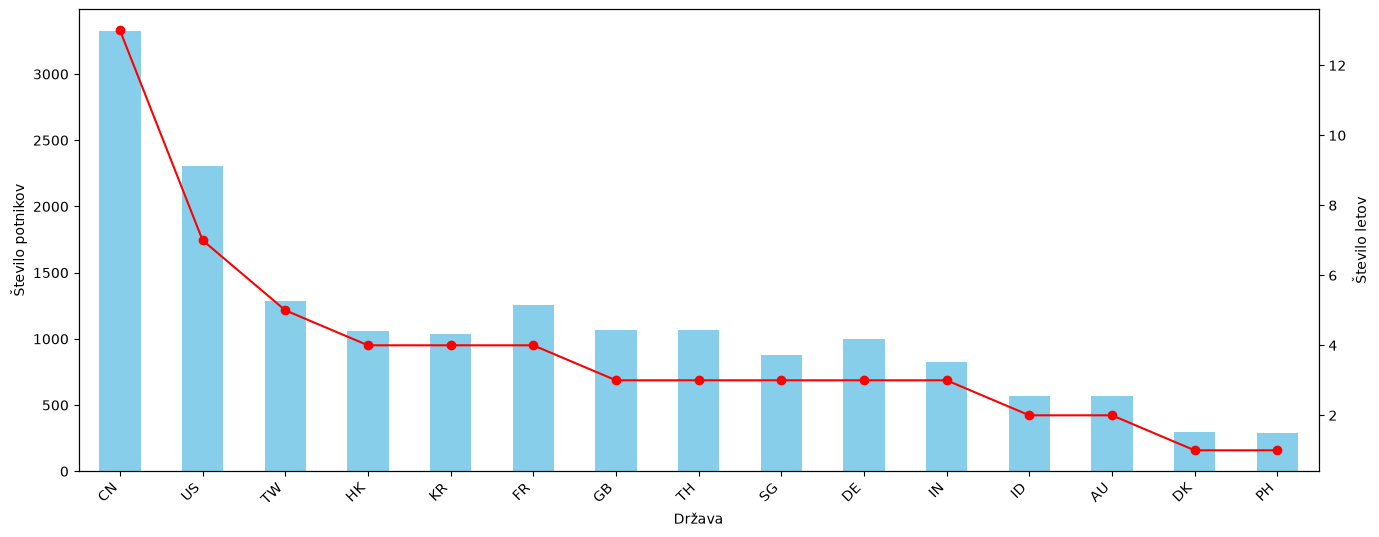

In [ ]:
m = pd.merge(flights, airports, left_on='arrivalAirportFS', right_on='fs')
merged = pd.merge(m, aircrafts, left_on='equipment', right_on='id')
merged = merged[merged['country'] != 'JP']
t1 = (
    merged.groupby('country')['pax']
    .count().rename('stevilo_letov')
    .sort_values(ascending=False))
t2 = (
    merged.groupby('country')['pax']
    .sum().rename('stevilo_potnikov')
    .sort_values(ascending=False))
top_destinacije = pd.merge(t1, t2, left_on='country', right_on='country').head(20)

ax = top_destinacije["stevilo_potnikov"].plot.bar(figsize=(16, 6), color="skyblue")
top_destinacije["stevilo_letov"].plot(ax=ax, secondary_y=True, color="red", marker="o")
ax.set_xlabel('Država')
ax.set_ylabel("Število potnikov")
ax.right_ax.set_ylabel("Število letov")
_ = ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")

Japonska je zelo gosto poseljena država z veliko populacijo, zato treba vsak dan prepeljati veliko število potnikov iz mesta v mesto. Zaradi učinkovitosti letalske družbe za lete znotraj Japonske uporabljajo velika letala, čeprav so zasnovana za veliko daljše razdalje. Tako se za lete, krajše od 2 ur, uporabljajo letala, ki lahko preletijo 14.000 km. V večini drugih držav to ni stroškovno učinkovito iz več razlogov, glavna pa sta zasedenost letov in vzdrževanje letal.
<br>
Spodaj je graf odvisnosti dolžine leta od dosega letala.

Text(0, 0.5, 'Trajanje leta')

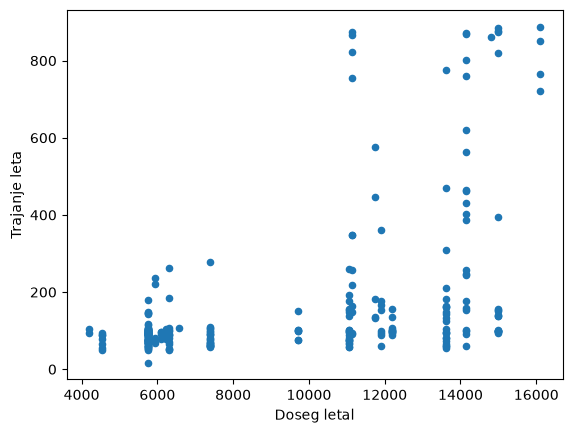

In [ ]:
merged = pd.merge(
    flights,
    aircrafts,
    left_on='equipment',
    right_on='id'
)
ax = merged.plot.scatter(x="range", y="flightDuration")
ax.set_xlabel('Doseg letal')
ax.set_ylabel("Trajanje leta")